<a href="https://colab.research.google.com/github/DHRUVCHARNE/AI-Learn-Notebooks/blob/main/makemore_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
words=open('/content/names.txt','r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [5]:
len(words)

32033

In [6]:
# Build the vocab of characters

chars = sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [7]:
# Build the dataset
block_size=3 # Context Length
X,Y = [],[]
for w in words[:5]:
  print(w)
  context=[0] * block_size
  for ch in w + '.':
    ix=stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context),'--->',itos[ix])
    context=context[1:]+[ix] # Crop and append
X=torch.tensor(X)
Y=torch.tensor(Y)


emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [8]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [9]:
No_Of_Dim=2
C=torch.randn((27,No_Of_Dim))
C[7]

tensor([-0.4391, -0.1935])

In [10]:
F.one_hot(torch.tensor(7),num_classes=27).float() @ C

tensor([-0.4391, -0.1935])

In [11]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [12]:
W1=torch.randn((6,100))
b1=torch.randn(100)


In [13]:
torch.cat([emb[:,0,:],emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([32, 6])

In [14]:
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([32, 6])

In [15]:
a=torch.arange(20)
a.shape

torch.Size([20])

In [16]:
a.view(2,2,5)

tensor([[[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]],

        [[10, 11, 12, 13, 14],
         [15, 16, 17, 18, 19]]])

In [17]:
emb.view(32,6) == torch.cat(torch.unbind(emb,1),1)

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [18]:
h=torch.tanh(emb.view(-1,6) @ W1 + b1)
h.shape

torch.Size([32, 100])

In [19]:
W2 = torch.randn((100,27))
b2=torch.randn(27)
logits = h @ W2 + b2

In [20]:
logits.shape

torch.Size([32, 27])

In [21]:
counts = logits.exp()
prob = counts / counts.sum(1,keepdim=True)
prob.shape

torch.Size([32, 27])

In [22]:
prob[0].sum()

tensor(1.)

In [23]:
loss = -prob[torch.arange(32),Y].log().mean()

In [24]:
#--- Now Formally :) ----

In [25]:
# Build the dataset
block_size=3 # Context Length
X,Y = [],[]
for w in words:
  context=[0] * block_size
  for ch in w + '.':
    ix=stoi[ch]
    X.append(context)
    Y.append(ix)
    context=context[1:]+[ix] # Crop and append
X=torch.tensor(X)
Y=torch.tensor(Y)


In [26]:
X.shape , Y.shape

(torch.Size([228146, 3]), torch.Size([228146]))

In [27]:
emb_dim=2

In [28]:
g=torch.Generator().manual_seed(2147483647) # For determinism
C = torch.randn((27,emb_dim),generator=g)
W1=torch.randn((6,100),generator=g)
b1=torch.randn(100,generator=g)
W2=torch.randn((100,27),generator=g)
b2=torch.randn(27,generator=g)
parameters=[C,W1,b1,W2,b2]

In [29]:
sum(p.nelement() for p in parameters) # No. of parameters

3481

In [30]:
for p in parameters:
  p.requires_grad=True

In [31]:
lre = torch.linspace(-3,0,1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [32]:
# lri,lossi=[],[]
for i in range(10):
  #Mini Batch
  ix=torch.randint(0,X.shape[0],(32,))
  # Forward Pass
  emb=C[X[ix]]
  h=torch.tanh(emb.view(-1,6) @ W1 + b1)
  logits=h @ W2 + b2
  # counts=logits.exp()
  # prob=counts / counts.sum(1,keepdim=True)
  # loss=-prob[torch.arange(32),Y].log().mean()
  loss=F.cross_entropy(logits,Y[ix])
  print(loss.item())
  # Backward Pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # Update
  for p in parameters:
    p.data += -0.07 * p.grad
  # lri.append(lre[i])
  # lossi.append(loss.item())
print(loss.item())

21.33633804321289
16.919509887695312
13.803946495056152
15.701727867126465
13.869247436523438
15.590570449829102
13.329325675964355
13.622754096984863
12.644051551818848
13.813931465148926
13.813931465148926


In [33]:
# plt.plot(lri,lossi)

In [34]:
emb=C[X]
h=torch.tanh(emb.view(-1,6) @ W1 + b1)
logits=h @ W2 + b2
loss=F.cross_entropy(logits,Y)
loss

tensor(12.2949, grad_fn=<NllLossBackward0>)

In [291]:
def build_dataset(words):
  block_size=3
  X,Y=[],[]
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix=stoi[ch]
      X.append(context)
      Y.append(ix)
      context=context[1:]+[ix]
  X=torch.tensor(X)
  Y=torch.tensor(Y)
  return X,Y
import random
random.seed(42)
random.shuffle(words)
n1=int(0.8 * len(words))
n2=int(0.9 * len(words))
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])


In [292]:
# Model Layers and Parameters
g=torch.Generator().manual_seed(2147483647)
C  = torch.randn((27,100), generator=g) * 0.1
W1 = torch.randn((300,300), generator=g) * 0.1
Wa = torch.randn((300,300), generator=g) * 0.1
Wb = torch.randn((300,300), generator=g) * 0.1
W2 = torch.randn((300,27), generator=g) * 0.1

b1 = torch.zeros(300)
ba = torch.zeros(300)
bb = torch.zeros(300)
b2 = torch.zeros(27)
parameters=[C,W1,b1,W2,b2,Wa,ba,Wb,bb]

In [293]:
sum(p.nelement() for p in parameters)

281727

In [295]:
for p in parameters:
  p.requires_grad=True

In [140]:
lre = torch.linspace(-3,0,10000)
lrs = 10**lre

In [311]:
# lri=[]
# lossi=[]
# stepi=[]
for i in range(100):
  # minibatch
  ix = torch.randint(0,Xtr.shape[0],(100,))
  # forward pass
  emb = C[Xtr[ix]]
  embcat = emb.reshape(emb.shape[0], -1)
  h = torch.tanh(embcat @ W1 + b1)
  h2 = torch.tanh(h @ Wa + ba)
  h3 = torch.tanh(h2 @ Wb + bb)
  logits = h3 @ W2 + b2
  loss = F.cross_entropy(logits,Ytr[ix])

  # Backward Pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # Update
  # lr = lrs[i]
  for p in parameters:
    p.data += -0.01 * p.grad
  # Track Stats
  # lri.append(lre[i])
  # lossi.append(loss.item())
  # stepi.append(i)



In [312]:
print(loss.item())

1.9699640274047852


In [313]:
emb=C[Xdev]
h=torch.tanh(emb.view(-1,300) @ W1 + b1)
logits=h @ W2 + b2
loss = F.cross_entropy(logits,Ydev)
loss

tensor(3.3233, grad_fn=<NllLossBackward0>)

In [314]:
emb=C[Xte]
h=torch.tanh(emb.view(-1,300) @ W1 + b1)
logits=h @ W2 + b2
loss = F.cross_entropy(logits,Yte)
loss

tensor(3.3198, grad_fn=<NllLossBackward0>)

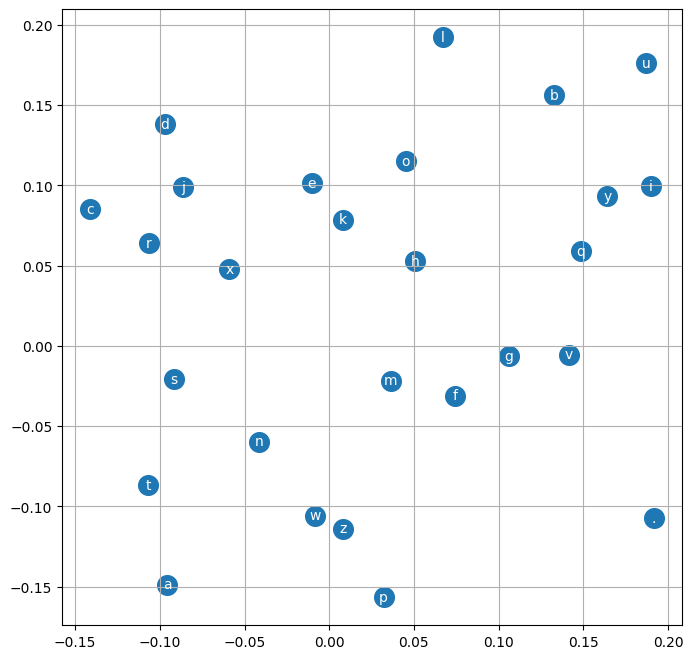

In [315]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha='center',va='center',color='white')
  plt.grid('minor')

In [319]:
# sample from model
g=torch.Generator().manual_seed(214748357)
for _ in range(250):
  out =[]
  context= [0] * block_size
  while True:
    emb = C[torch.tensor([context])]
    h=torch.tanh(emb.view(1,-1) @ W1+b1)
    h2 = torch.tanh(h @ Wa + ba)
    h3 = torch.tanh(h2 @ Wb + bb)
    logits = h3 @ W2 + b2
    probs = F.softmax(logits,dim=1)
    ix = torch.multinomial(probs,num_samples=1,generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix==0:
      break
  print(''.join(itos[i] for i in out))

eownie.
luna.
cene.
lirsh.
gaiphalyaizoreila.
sheletton.
jobrich.
len.
kiblayane.
jeer.
jaynnne.
mol.
darnci.
mah.
amelyn.
dale.
kordel.
kaxgirlin.
kachima.
tharton.
jaybel.
sha.
thyn.
cailahmya.
hak.
jahaleydona.
jor.
marleigh.
entobel.
ayahian.
aber.
dashimandya.
vedcorn.
kamaratelyn.
orda.
lavirdorcer.
dou.
tal.
ella.
nevis.
nacheyuka.
gen.
faudamirsee.
avel.
lyshishan.
brottynnte.
besmaizia.
sen.
nak.
jariekail.
febgedjoli.
aurimi.
lalon.
qur.
erlyn.
doni.
aan.
ande.
aotuimh.
sayaneyr.
habbota.
del.
ren.
alen.
sashannash.
cemer.
xadleylseem.
alanyl.
shanly.
son.
moten.
korlee.
epb.
loratkyalees.
jel.
san.
yuhel.
ous.
azleigh.
wlyne.
nomepn.
mariathi.
lanton.
shande.
kaila.
rohvin.
kayvx.
bronni.
cisheen.
zalij.
sea.
bryny.
sie.
gontel.
halle.
madiahamvir.
dhranalea.
lla.
welia.
chera.
marefzon.
adla.
sson.
ryunn.
mrsyn.
haine.
maha.
zir.
jaer.
asla.
elle.
aur.
ana.
zich.
shorya.
hzeyasheya.
elen.
aray.
omelanel.
brikyphebrd.
feriston.
esia.
arvia.
kaijoula.
nmaryan.
abvon.
tacia.
s